In [2]:
#%pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('../data/processed/BankChurners_clean.csv')
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt,Activity_Segment,Revolving_Use
0,0,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,Low,1
1,0,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,Low,1
2,0,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,Low,0
3,0,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,Low,1
4,0,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857,Low,0


### Para construir un perfil de cliente que cancela su tarjeta de crédito vamos a seguir una estructura ordenada

### 1. En primer lugar calcularemos la tasa de churn para tenerla como punto de referencia

In [4]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64

### Este es el número de referencia que usaremos durante todo el EDA: cualquier subgrupo que se aleje claramente de este 16% (por arriba o por abajo) será una pista relevante para el perfil que buscamos. También conviene tenerlo en cuenta para otra cosa: con un desbalance de clases de más o menos 84/16, cualquier media o proporción que calculemos sin segmentar estará dominada por el grupo mayoritario, por eso todo el resto del EDA se basa en comparar grupos (groupby por Attrition_Flag), nunca en mirar el dataset completo de forma agregada

### 2. Continuamos con el perfil demográfico

### 2.1 Edad

In [5]:
df.groupby('Attrition_Flag')['Customer_Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,46.262118,8.081157,26.0,41.0,46.0,52.0,73.0
1,1627.0,46.659496,7.665652,26.0,41.0,47.0,52.0,68.0


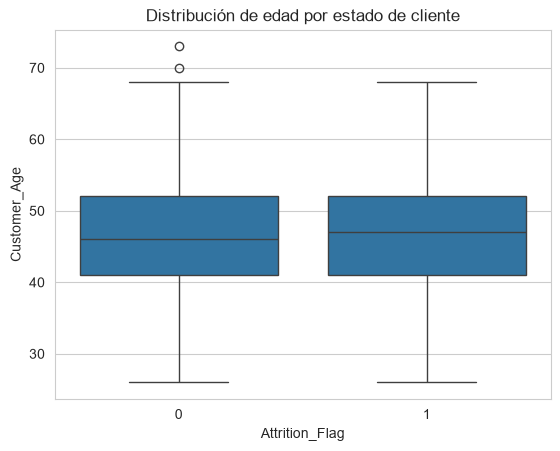

In [6]:
sns.boxplot(data=df, x='Attrition_Flag', y='Customer_Age')
plt.title('Distribución de edad por estado de cliente')
plt.show()

### Mdias prácticamente idénticas (46.26 vs 46.66 años), misma mediana casi (46 vs 47), mismos cuartiles. El boxplot lo confirma visualmente: la edad no diferencia al cliente que cancela

### 2.2 Género

In [7]:
pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Gender,,
0,85.384777,14.615223
1,82.642777,17.357223


### 14.6% de churn en hombres vs 17.4% en mujeres. Hay una diferencia de más o menos 2.7 puntos, ligeramente por encima de la base (16.07%) en mujeres y por debajo en hombres, pero es un efecto modesto: no constituye un perfil claro por sí solo

### 2.3 Dependientes, educación, estado civil e ingresos

In [8]:
pd.crosstab(df['Dependent_count'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Dependent_count,,
0,85.066372,14.933628
1,85.364527,14.635473
2,84.293785,15.706215
3,82.357247,17.642753
4,83.481576,16.518424
5,84.905660,15.094340


### Todas las categorías oscilan entre 14.6% y 17.6%, sin un patrón creciente o decreciente claro con el número de hijos/dependientes. Sin relación aparente

In [9]:
pd.crosstab(df['Education_Level'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Education_Level,,
College,84.797631,15.202369
Doctorate,78.935698,21.064302
Graduate,84.430946,15.569054
High School,84.798808,15.201192
Post-Graduate,82.170543,17.829457
Uneducated,84.061870,15.938130
Unknown,83.146807,16.853193


### La mayoría de categorías rondan 15-16%, muy cerca de la base. Hay dos que destacan algo: Doctorate (21.06%) y Post-Graduate (17.83%) están por encima. Conviene comprobar el tamaño de Doctorate, porque si es un grupo pequeño, ese porcentaje puede ser ruido estadístico, no una señal real. Comprobamos su tamaño:

In [10]:
df['Education_Level'].value_counts()

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

### Confirmado. Doctorate representa solo 451 clientes (4.5% del dataset), el grupo más pequeño de las 7 categorías, junto con Post-Graduate (516, también el segundo más pequeño). Con tamaños de muestra tan reducidos, una diferencia de 21% vs 16% de base puede deberse perfectamente a variabilidad aleatoria, no a un patrón real (con más o menos 451 casos y 16% de tasa esperada, el margen de error de la proporción es considerable)

In [11]:
pd.crosstab(df['Marital_Status'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Marital_Status,,
Divorced,83.823529,16.176471
Married,84.873053,15.126947
Single,83.058585,16.941415
Unknown,82.777036,17.222964


### Rango estrecho (15.1% - 17.2%), sin patrón destacable. Single y Unknown ligeramente por encima de la base, Married ligeramente por debajo, pero diferencias pequeñas

In [12]:
pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Income_Category,,
$120K +,82.668501,17.331499
$40K - $60K,84.860335,15.139665
$60K - $80K,86.519258,13.480742
$80K - $120K,84.234528,15.765472
Less than $40K,82.813816,17.186184
Unknown,83.183453,16.816547


### Rango similarmente estrecho (13.5% - 17.3%). Curiosamente, $120K + (17.3%) y Less than $40K (17.2%), los dos extremos de la escala de ingresos, tienen churn algo más alto que las categorías intermedias. Podría sugerir un patrón en forma de "U" (tanto rentas bajas como muy altas cancelan algo más), pero las diferencias son pequeñas (3-4 puntos) para considerarlo concluyente sin más evidencia

### Ninguna variable demográfica aporta una señal sólida y fiable sobre el churn. Las pequeñas desviaciones que vemos (Doctorate, género, ingresos extremos) son sutiles y, en al menos un caso, explicables por tamaño de muestra pequeño. No constituyen un perfil demográfico identificable

### 3. Vamos ahora a la vinculación del cliente con el banco

### 3.1 Antigüedad

In [13]:
df.groupby('Attrition_Flag')['Months_on_book'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,35.880588,8.021810,13.0,31.0,36.0,40.0,56.0
1,1627.0,36.178242,7.796548,13.0,32.0,36.0,40.0,56.0


### Prácticamente sin diferencia (35.88 vs 36.18 meses). Igual que pasó con la edad, la antigüedad no predice churn (un cliente nuevo no cancela más que uno veterano). Lo demográfico/temporal puro no discrimina

### 3.2. Número de productos contratados

In [14]:
pd.crosstab(df['Total_Relationship_Count'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Total_Relationship_Count,,
1,74.395604,25.604396
2,72.164119,27.835881
3,82.646421,17.353579
4,88.232218,11.767782
5,87.995769,12.004231
6,89.496249,10.503751


### Aquí aparece un patrón claro y monótono. Con 1 producto, el churn es 25.6%; con 2 productos, 27.8% (el pico); a partir de ahí cae de forma consistente: 17.4% (3), 11.8% (4), 12.0% (5), 10.5% (6). La diferencia entre el extremo bajo (más o menos 26-28%) y el alto (más o menos 10-12%) es de más de 2.5x. Esto confirma la hipótesis de vinculación: cuantos más productos tiene el cliente con el banco, menos probable es que cancele la tarjeta. Es uno de los hallazgos más sólidos hasta ahora

### 3.3. Meses de inactividad en los últimos 12

In [15]:
pd.crosstab(df['Months_Inactive_12_mon'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Months_Inactive_12_mon,,
0,48.275862,51.724138
1,95.521720,4.478280
2,84.613041,15.386959
3,78.523141,21.476859
4,70.114943,29.885057
5,82.022472,17.977528
6,84.677419,15.322581


### Patrón más complejo, con un detalle muy llamativo: el grupo 0 (sin ningún mes inactivo) tiene 51.7% de churn. Esto puede parecer contraintuitivo (¿el cliente más activo es el que más cancela?), pero hay una explicación lógica de negocio: probablemente sean clientes que cancelan la tarjeta poco después de usarla intensamente (cierre de cuenta a mitad de ciclo, sin pasar por un periodo de inactividad previo), no tienen tiempo de "enfriarse" antes de irse. Conviene verificar el tamaño de ese grupo 0, porque si es pequeño, igual que con Doctorate, hay que matizar su peso:

In [16]:
df['Months_Inactive_12_mon'].value_counts()

Months_Inactive_12_mon
3    3846
2    3282
1    2233
4     435
5     178
6     124
0      29
Name: count, dtype: int64

### Confirmado: el grupo Months_Inactive_12_mon = 0 tiene solo 29 clientes (0.29% del dataset), una muestra extremadamente pequeña. El 51.7% de churn calculado sobre ese grupo equivale a más o menos 15 clientes cancelados de 29 totales. Con un tamaño tan reducido, ese porcentaje tiene un margen de error enorme y no se puede considerar un patrón fiable, sino una posible casualidad estadística (o, como mucho, una pista a explorar con curiosidad, nunca como conclusión del perfil)

### El núcleo real de la variable está en las categorías 1, 2, 3, 4 (que concentran el 97% de los clientes: 2233, 3282, 3846, 435), y ahí sí el patrón es interpretable y fiable: el churn mínimo está en 1 mes inactivo (4.5%) y crece de forma consistente hasta 4 meses (29.9%). Las categorías 5 y 6 (178 y 124 casos) son más pequeñas pero todavía razonablemente robustas, y muestran cierta irregularidad (17.98% y 15.32%, ambas por debajo del pico de 4 meses), posiblemente porque ahí empiezan a mezclarse perfiles distintos (clientes inactivos de forma crónica pero estables, frente a los que cancelan)

### Número de contactos con el banco en los últimos 12 meses

In [17]:
pd.crosstab(df['Contacts_Count_12_mon'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Contacts_Count_12_mon,,
0,98.245614,1.754386
1,92.795197,7.204803
2,87.511621,12.488379
3,79.852071,20.147929
4,77.370690,22.629310
5,66.477273,33.522727
6,0.000000,100.000000


### El patrón más limpio y dramático de los cuatro. Crece de forma perfectamente monótona: 1.8% (0 contactos), 7.2%, 12.5%, 20.1%, 22.6%, 33.5%, 100% (6 contactos). El caso de 6 contactos con 100% de churn es extremo — todos los clientes que contactaron 6 veces con el banco en 12 meses acabaron cancelando. Igual que antes, verificamos el tamaño de ese grupo:

In [18]:
df['Contacts_Count_12_mon'].value_counts()

Contacts_Count_12_mon
3    3380
2    3227
1    1499
4    1392
0     399
5     176
6      54
Name: count, dtype: int64

### A diferencia del caso anterior, aquí sí podemos considerar el extremo como parte del patrón real, no como ruido. Y el resto de la tabla lo refuerza: el patrón es monótono y consistente en todas las categorías (0 a 6, sin excepciones ni irregularidades), algo que no ocurría en Months_Inactive. Esto convierte a Contacts_Count_12_mon en uno de los predictores más limpios y fiables encontrados hasta ahora: a mayor número de contactos con el banco en los últimos 12 meses, mayor probabilidad de cancelación, de forma prácticamente lineal.

### El cliente que cancela tiende a tener pocos productos contratados, cierta inactividad reciente, y sobre todo, un historial de múltiples contactos con el servicio del banco (lo cual sugiere fricciones o insatisfacción no resuelta antes del abandono). Este último punto es probablemente el hallazgo más accionable de todo el EDA hasta ahora: el banco tiene una señal de alerta temprana clara y monitorizable

### 4. Comportamiento del crédito

### 4.1 Límite del crédito

In [19]:
df.groupby('Attrition_Flag')['Credit_Limit'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,8726.877518,9084.969807,1438.3,2602.0,4643.5,11252.75,34516.0
1,1627.0,8136.039459,9095.334105,1438.3,2114.0,4178.0,9933.50,34516.0


### Apenas hay diferencia (8727 vs 8136), una variación pequeña. No es un predictor relevante por sí solo

### 4.2 Saldo revolving (deuda arrastrada)

In [20]:
df.groupby('Attrition_Flag')['Total_Revolving_Bal'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,1256.604118,757.745354,0.0,800.0,1364.0,1807.0,2517.0
1,1627.0,672.822987,921.385582,0.0,0.0,0.0,1303.5,2517.0


### Aquí sí hay una diferencia notable: los clientes que cancelan tienen una mediana de 0 (frente a 1364 en los que se quedan), y su media es mucho menor (672.8 vs 1256.6). Es decir, el cliente que cancela tiende a NO tener deuda revolving

### 4.3 Ratio de utilización

In [21]:
df.groupby('Attrition_Flag')['Avg_Utilization_Ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,0.296412,0.272568,0.0,0.055,0.211,0.52925,0.994
1,1627.0,0.162475,0.264458,0.0,0.000,0.000,0.23100,0.999


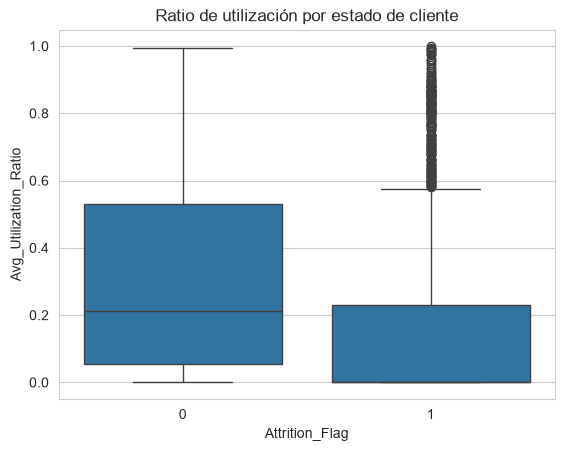

In [24]:
sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Utilization_Ratio')
plt.title('Ratio de utilización por estado de cliente')
plt.show()

### Mismo patrón, reforzado por el boxplot: la mediana del grupo que cancela es 0, mientras que el grupo que se queda tiene mediana 0.211 y un rango intercuartílico mucho más amplio (0.055 a 0.529). El boxplot muestra además algo muy revelador: el grupo que cancela (1) tiene una enorme cantidad de outliers superiores, es decir, dentro de los que cancelan hay dos subgrupos: una mayoría aplastante con utilización 0 (o casi) y un grupo minoritario con utilización muy alta, casi sin término medio

###  El patrón mayoritario de churn es el cliente de bajo uso/vinculación, pero existe un segmento minoritario (visible en los outliers del boxplot) con utilización muy alta que merece mención aparte. Vamos a cuantificarlo:

In [25]:
alta_utilizacion = df[df['Avg_Utilization_Ratio'] > 0.57]  # aprox. donde empiezan los outliers en el boxplot
alta_utilizacion['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
0    90.341463
1     9.658537
Name: proportion, dtype: float64

### Este resultado es clave y termina de aclarar el panorama: dentro del grupo de alta utilización (>0.57), solo el 9.66% cancela, un porcentaje incluso por debajo de la tasa base (16.07%)

### 4.4 Uso de revolving

In [22]:
pd.crosstab(df['Revolving_Use'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Revolving_Use,,
0,63.846154,36.153846
1,90.414000,9.586000


### Solo el 9.59% de los clientes que sí usan revolving cancelan, frente al 36.15% de los que no lo usan. La diferencia es enorme: más de 3.7 veces más churn entre quienes no arrastran deuda

### El cliente que cancela la tarjeta es, predominantemente, uno que apenas la usa como instrumento de crédito (no genera saldo revolving, no acumula utilización). Esto encaja perfectamente con el perfil que teníamos en el bloque 3 (pocos productos, cierta inactividad): es un cliente con bajo compromiso global con el producto, no uno atrapado por deuda